### Deep dive into bin5 sequencing data in 2nd generation (2D)

Bin 5 is **High Azidation** and should not have WT (the 2nd generation parent) in it. There are 16 samples in it. 

* We start with the BAM file instead of the fasta file using the [processbam.py](processbam.py) script.
* We reverse complement seqs when they are closer to WT but do not do any other filtering
* Saving the following for each CCS sequence in the BAM file
  * Number of passes (np)
  * length of the read
  * sequence
  * quality information

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import Bio
import Bio.SeqIO

import utils

### Get_bin5 shell script
```shell
cd data/scratch/bin5

demux_dir=/mnt/rdrive/promero2/UWBC-Dropbox/Large\ Datasets/r64247_20210830_223032/2_B01/demux/

cp "${demux_dir}/m64247_210901_044846.demux.bc1012_BAK8A_OA--bc1012_BAK8A_OA.bam" bin5.bam
```

In [2]:
datadir = "data/jared_PacBio_data_2"
bindir = "data/scratch/bin5"
binfile = f"{bindir}/bin5_stats.tsv"

In [3]:
WT_fasta = Bio.SeqIO.read(datadir + "/2D.fasta", format="fasta")
WT_DNA = WT_fasta.seq
WT = WT_DNA.translate()

In [4]:
df = pd.read_csv(binfile, sep="\t")
df["tilde_count"] = df.qual.str.count("~") # number of high quality bases
df.head()

,query_name,np,length,rc_better,ref_dist,seq,qual,tilde_count
0,m64247_210901_044846/63/ccs,19,1924,False,619,AACGTCGCTGCCGCACTCGATAATGTCGCCAACCACCATGTTGCCA...,~~~~~~~~~~[~~~~~~~~~~~~~~~~~|~~~~~~~~~~~~~~~~~...,765.0
1,m64247_210901_044846/255/ccs,23,895,False,6,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~...,822.0
2,m64247_210901_044846/268/ccs,17,894,False,473,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~V~~~~~~~~~~~~~...,744.0
3,m64247_210901_044846/314/ccs,4,894,False,539,CATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCA...,nejd]RL^R`bGw_aa>|VwYlX\RcmepnaYcI~~c<|dfLh\aY...,32.0
4,m64247_210901_044846/397/ccs,60,540,False,-1,NaN,NaN,NaN


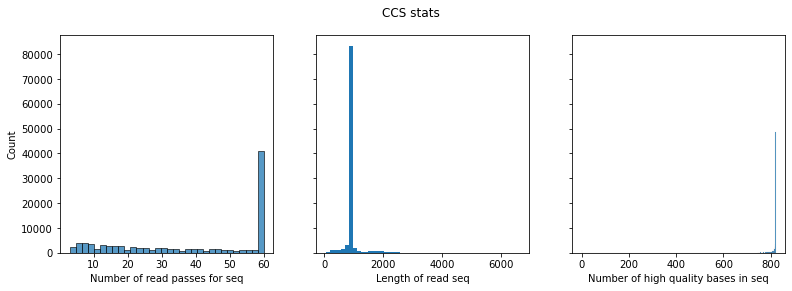

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(13, 4), sharey=True )
sns.histplot(data=df, x="np", ax=axs[0])
axs[0].set_xlabel("Number of read passes for seq")
axs[1].hist(df.length, bins=50)
axs[1].set_xlabel("Length of read seq")
sns.histplot(data=df, x="tilde_count", ax=axs[2])
axs[2].set_xlabel("Number of high quality bases in seq")
plt.suptitle("CCS stats")
pass

In [6]:
# select super high quality sequences
quality_seqs_mask = (df.np == 60) \
    & (df.tilde_count >= df.tilde_count.mode().item()) \
    & (df.length >= len(WT_DNA) \
    & (df.length <= len(WT_DNA)* 1.5)  )

# quality_seqs_mask = (df.np >= 0) \
#     & (df.tilde_count >= 0) \
#     & (df.length >= len(WT_DNA) \
#     & (df.length <= len(WT_DNA)* 1.5)  )

df_quality = df[quality_seqs_mask]
len(df_quality)

29485

In [7]:
df_quality_agg = df_quality.groupby("seq").agg(
        cnt=pd.NamedAgg(column="seq", aggfunc=len),
        ref_dist=pd.NamedAgg(column="ref_dist", 
                    aggfunc=lambda x: x.head(1).item())
    ).reset_index().sort_values("cnt", ascending=False).reset_index(drop=True)
df_quality_agg

,seq,cnt,ref_dist
0,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2950,3
1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2943,6
2,ATGCAGCATACCTATCCGGCTCAGCTGATGCGTTTTGGCACCGCGG...,2823,5
3,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2382,2
4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2296,4
...,...,...,...
1930,CACGAGGTTATCGCTCGCTTTGCGATTGGTTTTGCGCCCCCCGGCT...,1,597
1931,CACGAAGGTGCGTCCGGAAACCACTGCGGCAATGGCACGAATCATC...,1,609
1932,CACCTGGAATTACCTGCATCATCGGGGTTTCTACTTCCATAAAGCC...,1,605
1933,CACCGGGCCATGCGTGTGAGTTATGCAGATTGCGGCAACACTCGCG...,1,620


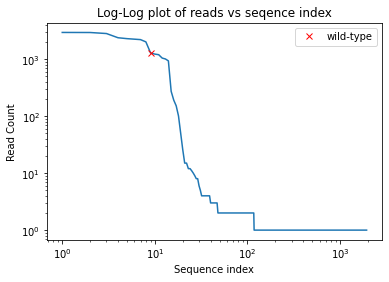

In [8]:
plt.plot(df_quality_agg.index + 1, df_quality_agg.cnt)
plt.xscale('log')
plt.yscale('log')
plt.ylabel("Read Count")
plt.xlabel("Sequence index")
plt.title("Log-Log plot of reads vs seqence index")
WT_index = df_quality_agg.index[df_quality_agg.ref_dist == 0].item()
ax = plt.gca()
ax.plot(WT_index + 1, df_quality_agg.iloc[WT_index].cnt, "xr", label="wild-type")
plt.legend()
pass

In [9]:
# Amino acid distance from wild-type
df_quality_agg["ref_aa_dist"] = df_quality_agg.seq.map(
        lambda x: utils.hamming_dist(Bio.Seq.Seq(x).translate(), WT))

In [10]:
df_quality_agg[:16]

,seq,cnt,ref_dist,ref_aa_dist
0,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2950,3,1
1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2943,6,2
2,ATGCAGCATACCTATCCGGCTCAGCTGATGCGTTTTGGCACCGCGG...,2823,5,0
3,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2382,2,2
4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2296,4,3
5,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2243,2,1
6,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2208,1,1
7,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2015,4,2
8,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,1284,0,0
9,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,1230,3,2


* WT appears at sequence \#9 
* A different parent DNA sequence appears at sequence \#3 and translates into the same AA seq as the parent
  * It has 5 mutations from the original and double the read count
* Sequence \#11 has a distance of 313 from the parent
  * There is a single base pair deletion in the CCS seq which accounts for this difference
  * These are extremely high quality reads so this is weird.
  * Same deal for sequence \#15 
  

In [11]:
# with open("/tmp/ordinal_bin5.fasta", "wt") as fh_out:
#     for i, seq in enumerate(df_quality_agg.seq[:16]):
#         print(f">s{i+1}\n{seq}", file=fh_out)